In [1]:
import numpy as np
import healpy as hp
#from scipy.interpolate import interp1d
import random
import input
from pathlib import Path
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import healsparse

# Use the normal or smoothed tensor fields: '_V2' (0.1Mpc) or '_smooth' (0.5Mpc) or '_smooth_1Mpc' (1Mpc)
smooth_flag_ss='_smooth'
smooth_flag_hc='_smooth_05Mpc'

# the number of galaxies per square arcminute to extract
gpam = 0.6

# The NSIDE value of the shear and weight maps
nside = 8192
# nside = 1024

#npix = 12*nside**2
#pix_size = np.sqrt(4.*np.pi*(180./np.pi*60)**2/npix)
#print('pixel size of shear maps is %f arcmin per side' % pix_size)

zfile_ss=np.loadtxt("z2ts.txt",delimiter=',')
z_list_ss=zfile_ss[1:58,0]
#snaplist_ss = np.flip(zfile_ss[1:58,1].astype(int))
snaplist_ss = zfile_ss[1:58,1].astype(int)
snaplist_hc = np.arange(0,51)
n_slices_ss = np.size(z_list_ss)

In [2]:
shell_array=np.array([( 0, 0.        , 0.        , 0.00802407,    0.        ,    0.        ,   33.82692451, 499),
       ( 1, 0.01617796, 0.00802407, 0.02446483,   68.08976014,   33.82692451,  102.7956806 , 491),
       ( 2, 0.03288798, 0.02446483, 0.04145078,  137.95197833,  102.7956806 ,  173.56606583, 483),
       ( 3, 0.05015674, 0.04145078, 0.05900948,  209.64554188,  173.56606583,  246.19811767, 475),
       ( 4, 0.06801275, 0.05900948, 0.07717042,  283.23157602,  246.19811767,  320.75382342, 467),
       ( 5, 0.08648649, 0.07717042, 0.0959651 ,  358.77289165,  320.75382342,  397.29701389, 459),
       ( 6, 0.10561056, 0.0959651 , 0.1154273 ,  436.3345261 ,  397.29701389,  475.89384179, 451),
       ( 7, 0.12541993, 0.1154273 , 0.13559322,  515.9835014 ,  475.89384179,  556.6121747 , 443),
       ( 8, 0.14595211, 0.13559322, 0.15650173,  597.78874582,  556.6121747 ,  639.52218942, 435),
       ( 9, 0.16724739, 0.15650173, 0.17819461,  681.82156213,  639.52218942,  724.69604871, 427),
       (10, 0.18934911, 0.17819461, 0.20071685,  768.15496588,  724.69604871,  812.20785472, 419),
       (11, 0.21230398, 0.20071685, 0.22411693,  856.86433196,  812.20785472,  902.13409898, 411),
       (12, 0.23616236, 0.22411693, 0.2484472 ,  948.02698421,  902.13409898,  994.55294915, 403),
       (13, 0.26097867, 0.2484472 , 0.27376426, 1041.72218627,  994.55294915, 1089.54494655, 395),
       (14, 0.28681178, 0.27376426, 0.30012937, 1138.0315665 , 1089.54494655, 1187.19250664, 387),
       (15, 0.31372549, 0.30012937, 0.32760898, 1237.0383605 , 1187.19250664, 1287.57995581, 379),
       (16, 0.34178905, 0.32760898, 0.3562753 , 1338.8281604 , 1287.57995581, 1390.7939275 , 371),
       (17, 0.37107776, 0.3562753 , 0.3862069 , 1443.48833012, 1390.7939275 , 1496.92257431, 363),
       (18, 0.40167364, 0.3862069 , 0.41748942, 1551.10810124, 1496.92257431, 1606.05637443, 355),
       (19, 0.43366619, 0.41748942, 0.45021645, 1661.77894335, 1606.05637443, 1718.28747402, 347),
       (20, 0.46715328, 0.45021645, 0.4844904 , 1775.5937681 , 1718.28747402, 1833.70986346, 339),
       (21, 0.50224215, 0.4844904 , 0.5204236 , 1892.64780673, 1833.70986346, 1952.4197351 , 331),
       (22, 0.53905054, 0.5204236 , 0.55813953, 2013.03790386, 1952.4197351 , 2074.51471358, 323),
       (23, 0.57770801, 0.55813953, 0.59777424, 2136.86280717, 2074.51471358, 2200.09483231, 315),
       (24, 0.61835749, 0.59777424, 0.63947798, 2264.22354142, 2200.09483231, 2329.26181785, 307),
       (25, 0.66115702, 0.63947798, 0.68341709, 2395.222714  , 2329.26181785, 2462.11954376, 299),
       (26, 0.70628183, 0.68341709, 0.72977625, 2529.96563935, 2462.11954376, 2598.77447039, 291),
       (27, 0.7539267 , 0.72977625, 0.77876106, 2668.55967103, 2598.77447039, 2739.33509332, 283),
       (28, 0.8043088 , 0.77876106, 0.83060109, 2811.11489499, 2739.33509332, 2883.91329458, 275),
       (29, 0.85767098, 0.83060109, 0.88555347, 2957.74471195, 2883.91329458, 3032.62379981, 267),
       (30, 0.91428571, 0.88555347, 0.94390716, 3108.56551872, 3032.62379981, 3185.585221  , 259),
       (31, 0.97445972, 0.94390716, 1.00598802, 3263.69840713, 3185.585221  , 3342.92089226, 251),
       (32, 1.03853955, 1.00598802, 1.07216495, 3423.26884711, 3342.92089226, 3504.75890427, 243),
       (33, 1.10691824, 1.07216495, 1.14285714, 3587.40823962, 3504.75890427, 3671.23433143, 235),
       (34, 1.18004338, 1.14285714, 1.21854305, 3756.25516154, 3671.23433143, 3842.48927225, 227),
       (35, 1.25842697, 1.21854305, 1.29977117, 3929.95591962, 3842.48927225, 4018.67515279, 219),
       (36, 1.34265734, 1.29977117, 1.3871734 , 4108.66757702, 4018.67515279, 4199.95460376, 211),
       (37, 1.43341404, 1.3871734 , 1.48148148, 4292.55853376, 4199.95460376, 4386.50278292, 203),
       (38, 1.53148615, 1.48148148, 1.58354756, 4481.81195736, 4386.50278292, 4578.51162418, 195),
       (39, 1.63779528, 1.58354756, 1.69436997, 4676.62863396, 4578.51162418, 4776.19124662, 187),
       (40, 1.75342466, 1.69436997, 1.81512605, 4877.22947426, 4776.19124662, 4979.77514376, 179),
       (41, 1.87965616, 1.81512605, 1.94721408, 5083.86168973, 4979.77514376, 5189.52458872, 171),
       (42, 2.01801802, 1.94721408, 2.09230769, 5296.80155803, 5189.52458872, 5405.73309568, 163),
       (43, 2.170347  , 2.09230769, 2.25242718, 5516.36251362, 5405.73309568, 5628.73579522, 155),
       (44, 2.33887043, 2.25242718, 2.43003413, 5742.9022103 , 5628.73579522, 5858.91464917, 147),
       (45, 2.52631579, 2.43003413, 2.62815884, 5976.83051086, 5858.91464917, 6096.71168482, 139),
       (46, 2.73605948, 2.62815884, 2.85057471, 6218.62457947, 6096.71168482, 6342.64105531, 131),
       (47, 2.97233202, 2.85057471, 3.10204082, 6468.83903656, 6342.64105531, 6597.30404434, 123),
       (48, 3.24050633, 3.10204082, 3.38864629, 6728.12914664, 6597.30404434, 6861.41540031, 115),
       (49, 3.54751131, 3.38864629, 3.71830986, 6997.27342671, 6861.41540031, 7135.8246557 , 107),
       (50, 3.90243902, 3.71830986, 4.10152284, 7277.20418209, 7135.8246557 , 7421.56086228,  99)],
      dtype=[('ishell', '<i8'), ('zsnapshot', '<f8'), ('zmin', '<f8'), ('zmax', '<f8'), ('chisnapshot', '<f8'), ('chimin', '<f8'), ('chimax', '<f8'), ('snapshot_id', '<i8')])

# Compute shell thickness factor H0/chi_shell
#SkySim: Chi_shell = 114
#print('SkySim: ',71/114)

#HACC: Chi_shell varies with redshift
#cosmo = FlatLambdaCDM(H0=71, Om0=0.2648, Tcmb0=2.725)
delta_chi = shell_array['chimax'] - shell_array['chimin']
z_shell = shell_array['zsnapshot']

In [3]:
!ls /pscratch/sd/j/jmena/HOS_Sims/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/shell_hacc_seed0_nside8192_t11_imap0.fits

/pscratch/sd/j/jmena/HOS_Sims/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/shell_hacc_seed0_nside8192_t11_imap0.fits


In [4]:
# print(np.size(snaplist_ss))
#snaplist_ss

In [5]:
def fname_tidal_ss(snap_no):
    return "/global/cfs/cdirs/lsst/groups/WL/projects/wl-massmap/IA-infusion//SkySim5000/tidalfield/tidal_field_map_"+str(snaplist_ss[snap_no])+"_allsky"+smooth_flag_ss+".npy"

def fname_tidal_hc(snap_no):
    return "/global/cfs/cdirs/lsst/groups/WL/projects/wl-massmap/IA-infusion/BCM/dmo/tidalfield/tidal_field_map_"+str(snaplist_hc[snap_no])+"_allsky"+smooth_flag_hc+".npy"

def fname_tidal_pollux11(snap_no):
    return "/pscratch/sd/j/jmena/HOS_Sims_baryonified/dmb/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/shell_hacc_seed0_nside8192_t11_imap"+str(snaplist_hc[snap_no])+".fits"
def fname_tidal_pollux22(snap_no):
    return "/pscratch/sd/j/jmena/HOS_Sims_baryonified/dmb/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/shell_hacc_seed0_nside8192_t22_imap"+str(snaplist_hc[snap_no])+".fits"
def fname_tidal_pollux12(snap_no):
    return "/pscratch/sd/j/jmena/HOS_Sims_baryonified/dmb/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/shell_hacc_seed0_nside8192_t12_imap"+str(snaplist_hc[snap_no])+".fits"
def fname_tidal_pollux11_smooth(snap_no):
    return "/pscratch/sd/j/jmena/HOS_Sims_baryonified/dmb/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/shell_hacc_seed0_nside8192_t11_0.5Mpc_imap"+str(snaplist_hc[snap_no])+".fits"
def fname_tidal_pollux22_smooth(snap_no):
    return "/pscratch/sd/j/jmena/HOS_Sims_baryonified/dmb/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/shell_hacc_seed0_nside8192_t22_0.5Mpc_imap"+str(snaplist_hc[snap_no])+".fits"
def fname_tidal_pollux12_smooth(snap_no):
    return "/pscratch/sd/j/jmena/HOS_Sims_baryonified/dmb/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/shell_hacc_seed0_nside8192_t12_0.5Mpc_imap"+str(snaplist_hc[snap_no])+".fits"

def fname_density_ss(snap_no):
    return "/global/cfs/cdirs/lsst/groups/WL/projects/wl-massmap/IA-infusion//SkySim5000//density/density_map_"+str(snaplist_ss[snap_no])+"_dens_allsky.npy"

def hpmap_density_ss(snap_no):
    hpmap_den = np.load(fname_density_ss(snap_no))
    # Normalize the maps correctly:       
    mean_rho = (np.mean(hpmap_den)) # no factor of 8.0 since we have full sky data here
    hpmap_den /= mean_rho 
    hpmap_den -= 1
    return hpmap_den
    
def hpmap_tidal_ss(snap_no):
    hpmap_tidal_ = np.load(fname_tidal_ss(snap_no))
    Norm_empirical = 0.6525 
    hpmap_tidal_ *= Norm_empirical
    return hpmap_tidal_

def hpmap_tidal_hc(snap_no):
    hpmap_tidal_ = np.load(fname_tidal_hc(snap_no))
    #Norm_empirical = 0.6525 
    norm_HACC = 4/3
    Norm_empirical = 71/delta_chi[snap_no]/norm_HACC
    hpmap_tidal_ *= Norm_empirical
    return hpmap_tidal_

def hpmap_tidal_pollux(snap_no):

    
    a = healsparse.HealSparseMap.read(fname_tidal_pollux11(snap_no))
    tmp = a.generate_healpix_map()
    
    # turn masked pixels to zero.
    tmp[tmp<-1.0e+30]=0

    hpmap_tidal_ = np.zeros([hp.nside2npix(8192),3])
    
    #Note, these maps are Nested ordered, not ring ordered.
    hpmap_tidal_[:,0]= hp.reorder(tmp, n2r = True)
    del tmp
    
    a = healsparse.HealSparseMap.read(fname_tidal_pollux22(snap_no))
    tmp = a.generate_healpix_map()
    
    # turn masked pixels to zero.
    tmp[tmp<-1.0e+30]=0

    #Note, these maps are Nested ordered, not ring ordered.
    hpmap_tidal_[:,1]= hp.reorder(tmp, n2r = True)
    del tmp

    a = healsparse.HealSparseMap.read(fname_tidal_pollux12(snap_no))
    tmp = a.generate_healpix_map()
    
    # turn masked pixels to zero.
    tmp[tmp<-1.0e+30]=0

    #Note, these maps are Nested ordered, not ring ordered.
    hpmap_tidal_[:,2]= hp.reorder(tmp, n2r = True)
    del tmp

    
    # Visualize:
    #hp.mollview(np.log(hpmap_tidal_), nest=False)
    #plt.show()

    
    Norm_empirical = 0.6525 
    hpmap_tidal_ *= Norm_empirical
    return hpmap_tidal_

def hpmap_tidal_pollux_smooth(snap_no):

    
    a = healsparse.HealSparseMap.read(fname_tidal_pollux11_smooth(snap_no))
    tmp = a.generate_healpix_map()
    
    # turn masked pixels to zero.
    tmp[tmp<-1.0e+30]=0

    hpmap_tidal_ = np.zeros([hp.nside2npix(8192),3])
    
    #Note, these maps are Nested ordered, not ring ordered.
    hpmap_tidal_[:,0]= hp.reorder(tmp, n2r = True)
    del tmp
    
    a = healsparse.HealSparseMap.read(fname_tidal_pollux22_smooth(snap_no))
    tmp = a.generate_healpix_map()
    
    # turn masked pixels to zero.
    tmp[tmp<-1.0e+30]=0

    #Note, these maps are Nested ordered, not ring ordered.
    hpmap_tidal_[:,1]= hp.reorder(tmp, n2r = True)
    del tmp

    a = healsparse.HealSparseMap.read(fname_tidal_pollux12_smooth(snap_no))
    tmp = a.generate_healpix_map()
    
    # turn masked pixels to zero.
    tmp[tmp<-1.0e+30]=0

    #Note, these maps are Nested ordered, not ring ordered.
    hpmap_tidal_[:,2]= hp.reorder(tmp, n2r = True)
    del tmp

    
    # Visualize:
    #hp.mollview(np.log(hpmap_tidal_), nest=False)
    #plt.show()

    
    Norm_empirical = 0.6525 
    hpmap_tidal_ *= Norm_empirical
    return hpmap_tidal_

SkySim
s11: -3.7453895 15.851727 8.443927e-05
s22: -4.9505467 17.912966 -8.42131e-05
s12: -9.2410965 8.815963 1.9703192e-07


/tmp/ipykernel_1805685/495806027.py:13: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(hpmap_tidal_ss(snap_no)[:,0]), nest=False)
/tmp/ipykernel_1805685/495806027.py:13: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log(hpmap_tidal_ss(snap_no)[:,0]), nest=False)


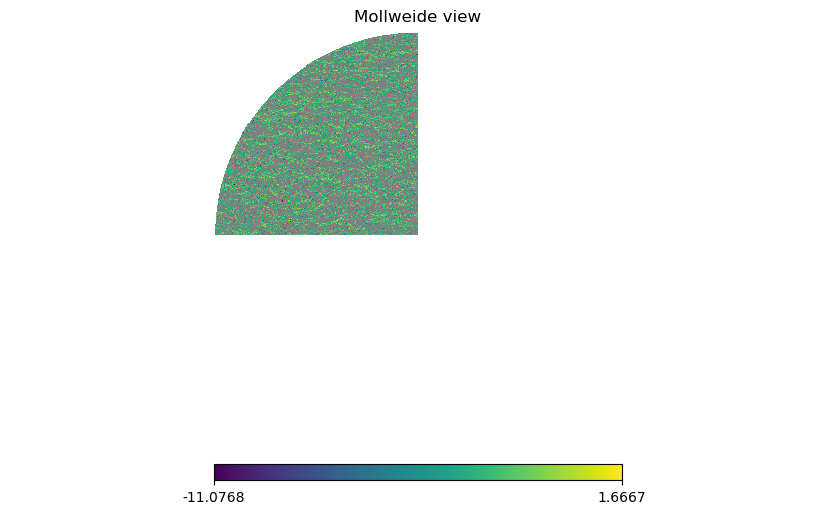

/tmp/ipykernel_1805685/495806027.py:16: RuntimeWarning: divide by zero encountered in log
  hp.cartview(np.log(hpmap_tidal_ss(snap_no)[:,0]), cbar=True, lonra=lonra, latra=latra,
/tmp/ipykernel_1805685/495806027.py:16: RuntimeWarning: invalid value encountered in log
  hp.cartview(np.log(hpmap_tidal_ss(snap_no)[:,0]), cbar=True, lonra=lonra, latra=latra,


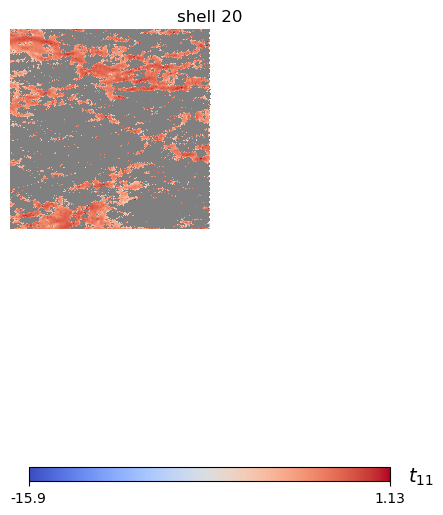

/tmp/ipykernel_1805685/495806027.py:24: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(hpmap_tidal_ss(snap_no)[:,1]), nest=False)
/tmp/ipykernel_1805685/495806027.py:24: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log(hpmap_tidal_ss(snap_no)[:,1]), nest=False)


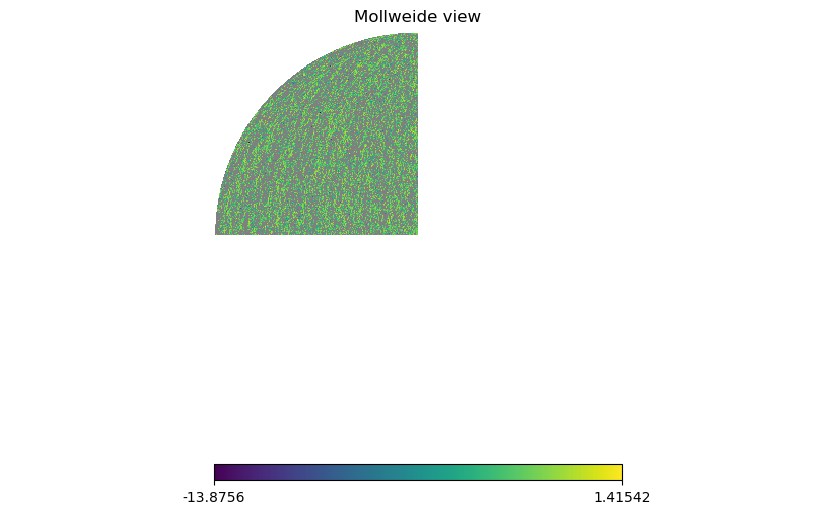

/tmp/ipykernel_1805685/495806027.py:27: RuntimeWarning: divide by zero encountered in log
  hp.cartview(np.log(hpmap_tidal_ss(snap_no)[:,1]), cbar=True, lonra=lonra, latra=latra,
/tmp/ipykernel_1805685/495806027.py:27: RuntimeWarning: invalid value encountered in log
  hp.cartview(np.log(hpmap_tidal_ss(snap_no)[:,1]), cbar=True, lonra=lonra, latra=latra,


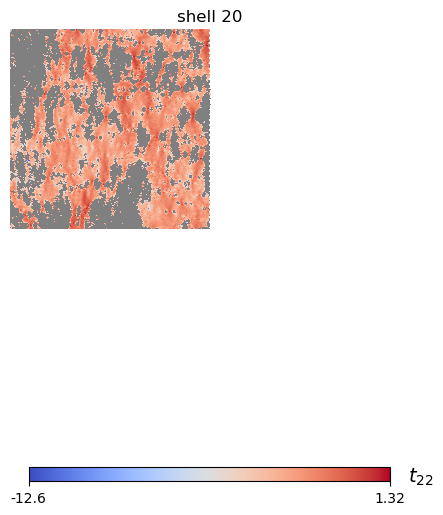

/tmp/ipykernel_1805685/495806027.py:35: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(hpmap_tidal_ss(snap_no)[:,2]), nest=False)
/tmp/ipykernel_1805685/495806027.py:35: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log(hpmap_tidal_ss(snap_no)[:,2]), nest=False)


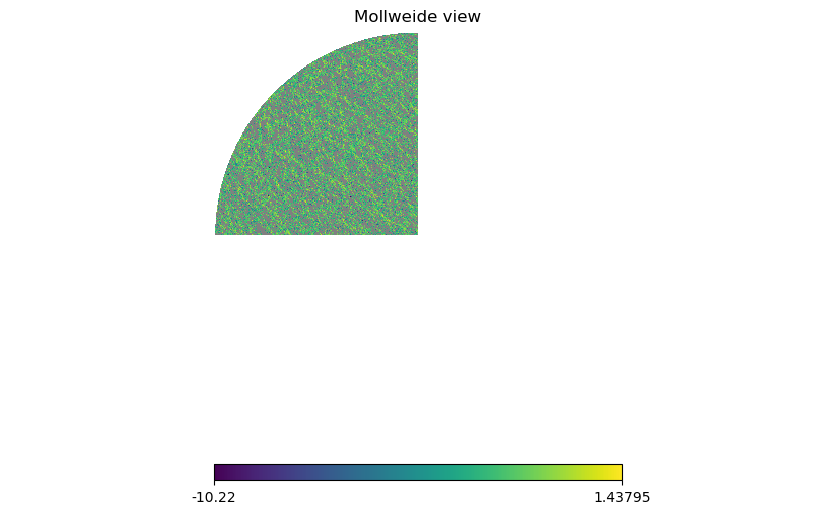

/tmp/ipykernel_1805685/495806027.py:38: RuntimeWarning: divide by zero encountered in log
  hp.cartview(np.log(hpmap_tidal_ss(snap_no)[:,2]), cbar=True, lonra=lonra, latra=latra,
/tmp/ipykernel_1805685/495806027.py:38: RuntimeWarning: invalid value encountered in log
  hp.cartview(np.log(hpmap_tidal_ss(snap_no)[:,2]), cbar=True, lonra=lonra, latra=latra,


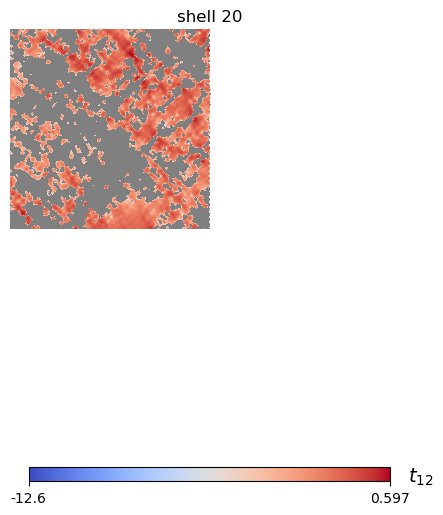

In [6]:
snap_no = 20
# print("over density:", np.min(hpmap_density_ss(snap_no)), np.max(hpmap_density_ss(snap_no)), np.mean(hpmap_density_ss(snap_no)))
print("SkySim")
print("s11:",np.min(hpmap_tidal_ss(snap_no)[:,0]), np.max(hpmap_tidal_ss(snap_no)[:,0]), np.mean(hpmap_tidal_ss(snap_no)[:,0]))
print("s22:",np.min(hpmap_tidal_ss(snap_no)[:,1]), np.max(hpmap_tidal_ss(snap_no)[:,1]), np.mean(hpmap_tidal_ss(snap_no)[:,1]))
print("s12:",np.min(hpmap_tidal_ss(snap_no)[:,2]), np.max(hpmap_tidal_ss(snap_no)[:,2]), np.mean(hpmap_tidal_ss(snap_no)[:,2]))


# Visualize:
lonra = [-3, 3]
latra = [-3, 3]

hp.mollview(np.log(hpmap_tidal_ss(snap_no)[:,0]), nest=False)
plt.show()

hp.cartview(np.log(hpmap_tidal_ss(snap_no)[:,0]), cbar=True, lonra=lonra, latra=latra,
            nest=False,
            title="shell "+str(snap_no),
            # min=-10, max=0,
            cmap=plt.cm.coolwarm,            
            norm=None, unit='$t_{11}$')
plt.show()

hp.mollview(np.log(hpmap_tidal_ss(snap_no)[:,1]), nest=False)
plt.show()

hp.cartview(np.log(hpmap_tidal_ss(snap_no)[:,1]), cbar=True, lonra=lonra, latra=latra,
            nest=False,
            title="shell "+str(snap_no),
            # min=-10, max=0,
            cmap=plt.cm.coolwarm,            
            norm=None, unit='$t_{22}$')
plt.show()

hp.mollview(np.log(hpmap_tidal_ss(snap_no)[:,2]), nest=False)
plt.show()

hp.cartview(np.log(hpmap_tidal_ss(snap_no)[:,2]), cbar=True, lonra=lonra, latra=latra,
            nest=False,
            title="shell "+str(snap_no),
            # min=-10, max=0,
            cmap=plt.cm.coolwarm,            
            norm=None, unit='$t_{12}$')
plt.show()

In [10]:
print("HACC")
print("s11:",np.min(hpmap_tidal_hc(snap_no)[:,0]), np.max(hpmap_tidal_hc(snap_no)[:,0]), np.mean(hpmap_tidal_hc(snap_no)[:,0]))
print("s22:",np.min(hpmap_tidal_hc(snap_no)[:,1]), np.max(hpmap_tidal_hc(snap_no)[:,1]), np.mean(hpmap_tidal_hc(snap_no)[:,1]))
print("s12:",np.min(hpmap_tidal_hc(snap_no)[:,2]), np.max(hpmap_tidal_hc(snap_no)[:,2]), np.mean(hpmap_tidal_hc(snap_no)[:,2]))

HACC
s11: -6.437547 32.38669 0.0006880032
s22: -4.286604 32.92798 -0.00069392397
s12: -10.15831 16.724918 -3.5105768e-06


POLLUX
s11: -4.89352567076683 29.46706169128418 -3.377804372669544e-05
s22: -13.508128209114075 12.500681490898131 -0.00031478963396398195
s12: -5.432884397506713 28.17677470207214 3.377804362334294e-05


/tmp/ipykernel_1805685/3383014475.py:12: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(t_maps[:,0]), nest=False)
/tmp/ipykernel_1805685/3383014475.py:12: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log(t_maps[:,0]), nest=False)


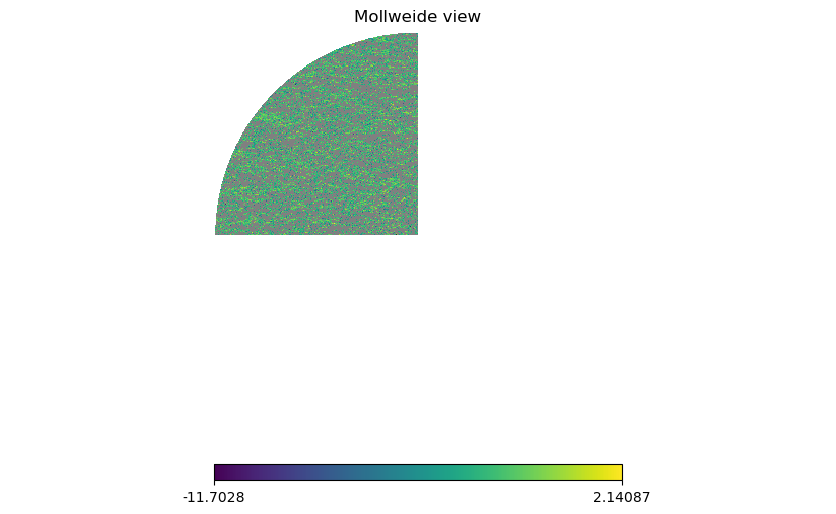

/tmp/ipykernel_1805685/3383014475.py:15: RuntimeWarning: divide by zero encountered in log
  hp.cartview(np.log(t_maps[:,0]), cbar=True, lonra=lonra, latra=latra,
/tmp/ipykernel_1805685/3383014475.py:15: RuntimeWarning: invalid value encountered in log
  hp.cartview(np.log(t_maps[:,0]), cbar=True, lonra=lonra, latra=latra,


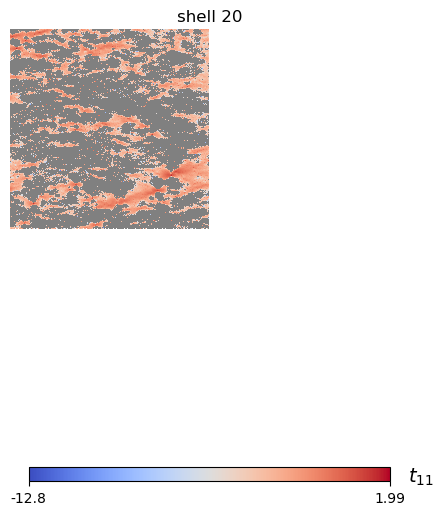

/tmp/ipykernel_1805685/3383014475.py:23: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(t_maps[:,1]), nest=False)
/tmp/ipykernel_1805685/3383014475.py:23: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log(t_maps[:,1]), nest=False)


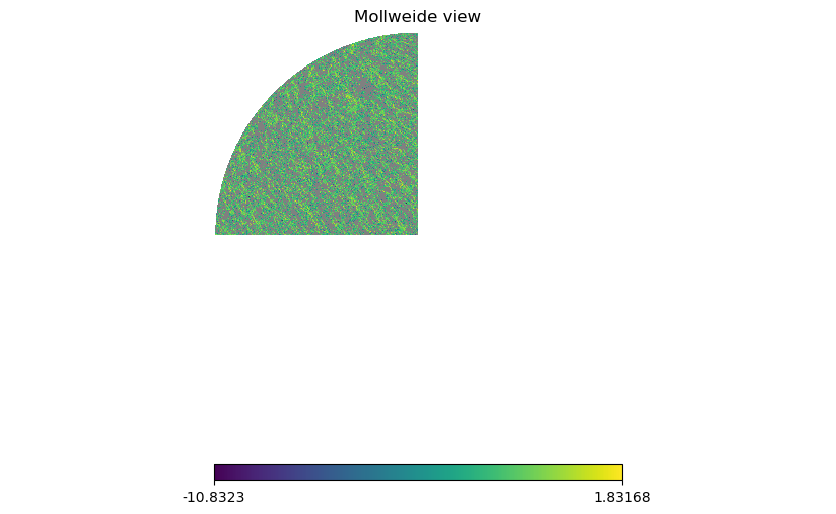

/tmp/ipykernel_1805685/3383014475.py:26: RuntimeWarning: divide by zero encountered in log
  hp.cartview(np.log(t_maps[:,1]), cbar=True, lonra=lonra, latra=latra,
/tmp/ipykernel_1805685/3383014475.py:26: RuntimeWarning: invalid value encountered in log
  hp.cartview(np.log(t_maps[:,1]), cbar=True, lonra=lonra, latra=latra,


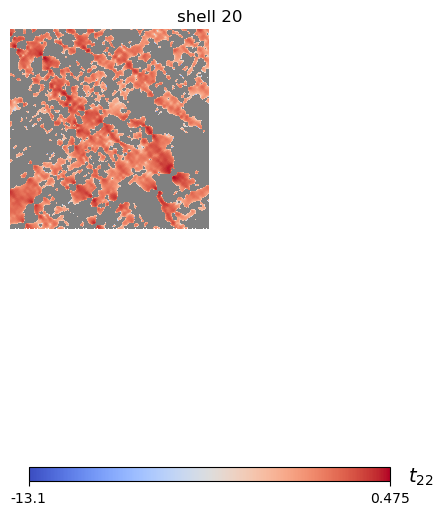

/tmp/ipykernel_1805685/3383014475.py:34: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(t_maps[:,2]), nest=False)
/tmp/ipykernel_1805685/3383014475.py:34: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log(t_maps[:,2]), nest=False)


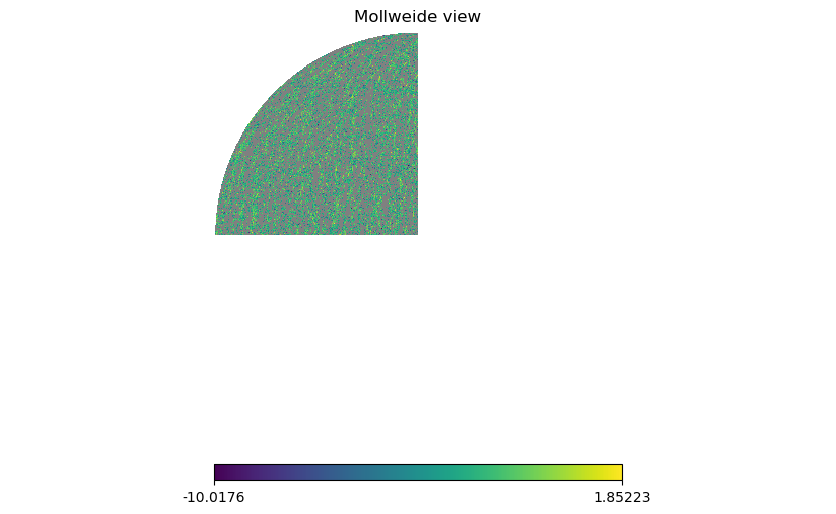

/tmp/ipykernel_1805685/3383014475.py:37: RuntimeWarning: divide by zero encountered in log
  hp.cartview(np.log(t_maps[:,2]), cbar=True, lonra=lonra, latra=latra,
/tmp/ipykernel_1805685/3383014475.py:37: RuntimeWarning: invalid value encountered in log
  hp.cartview(np.log(t_maps[:,2]), cbar=True, lonra=lonra, latra=latra,


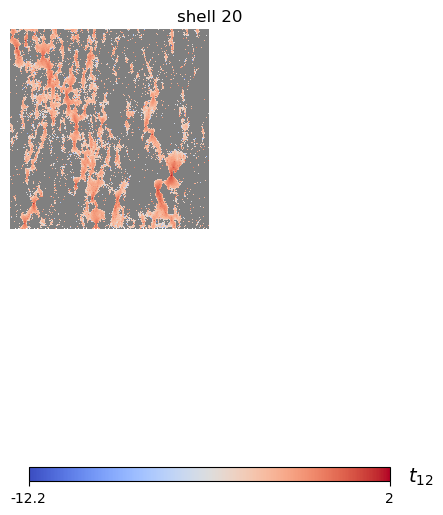

In [7]:
print("POLLUX")
t_maps = hpmap_tidal_pollux_smooth(snap_no)
print("s11:",np.min(t_maps[:,0]),np.max(t_maps[:,0]), np.mean(t_maps[:,0]))
print("s22:",np.min(t_maps[:,1]),np.max(t_maps[:,1]), np.mean(t_maps[:,1]))
print("s12:",np.min(t_maps[:,2]),np.max(t_maps[:,2]), np.mean(t_maps[:,2]))

#print("s11:",np.min(hpmap_tidal_pollux(snap_no)[:,0]), np.max(hpmap_tidal_pollux(snap_no)[:,0]), np.mean(hpmap_tidal_pollux(snap_no)[:,0]))
#print("s22:",np.min(hpmap_tidal_pollux(snap_no)[:,1]), np.max(hpmap_tidal_pollux(snap_no)[:,1]), np.mean(hpmap_tidal_pollux(snap_no)[:,1]))
#print("s12:",np.min(hpmap_tidal_pollux(snap_no)[:,2]), np.max(hpmap_tidal_pollux(snap_no)[:,2]), np.mean(hpmap_tidal_pollux(snap_no)[:,2]))


hp.mollview(np.log(t_maps[:,0]), nest=False)
plt.show()

hp.cartview(np.log(t_maps[:,0]), cbar=True, lonra=lonra, latra=latra,
            nest=False,
            title="shell "+str(snap_no),
            # min=-10, max=0,
            cmap=plt.cm.coolwarm,            
            norm=None, unit='$t_{11}$')
plt.show()

hp.mollview(np.log(t_maps[:,1]), nest=False)
plt.show()

hp.cartview(np.log(t_maps[:,1]), cbar=True, lonra=lonra, latra=latra,
            nest=False,
            title="shell "+str(snap_no),
            # min=-10, max=0,
            cmap=plt.cm.coolwarm,            
            norm=None, unit='$t_{22}$')
plt.show()

hp.mollview(np.log(t_maps[:,2]), nest=False)
plt.show()

hp.cartview(np.log(t_maps[:,2]), cbar=True, lonra=lonra, latra=latra,
            nest=False,
            title="shell "+str(snap_no),
            # min=-10, max=0,
            cmap=plt.cm.coolwarm,            
            norm=None, unit='$t_{12}$')
plt.show()


POLLUX
s11: -25.55490921020508 61.6432190322876 0.00014891311875337657
s22: -23.257725591659543 55.752459068298336 -0.00014891311847257244
s12: -66.43279563903808 71.21108173370361 -0.0002464810020610505


/tmp/ipykernel_1190604/723612356.py:12: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(t_maps[:,0]), nest=False)
/tmp/ipykernel_1190604/723612356.py:12: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log(t_maps[:,0]), nest=False)


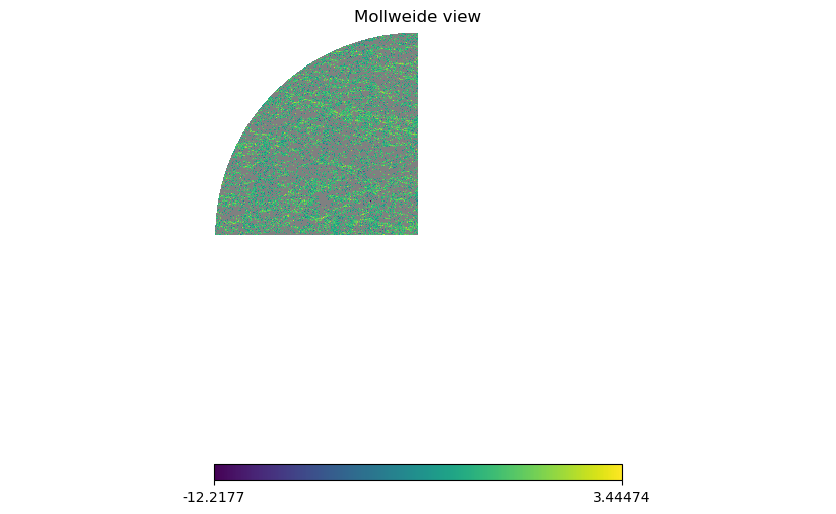

/tmp/ipykernel_1190604/723612356.py:15: RuntimeWarning: divide by zero encountered in log
  hp.cartview(np.log(t_maps[:,0]), cbar=True, lonra=lonra, latra=latra,
/tmp/ipykernel_1190604/723612356.py:15: RuntimeWarning: invalid value encountered in log
  hp.cartview(np.log(t_maps[:,0]), cbar=True, lonra=lonra, latra=latra,


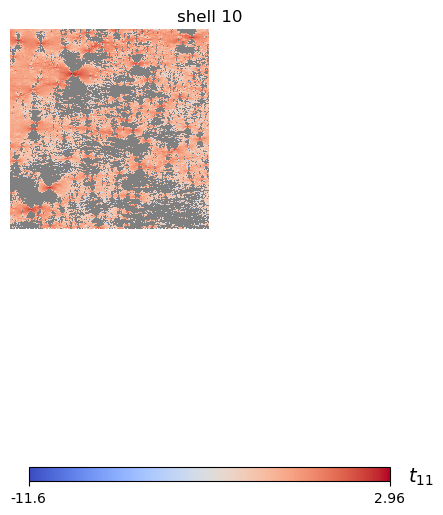

/tmp/ipykernel_1190604/723612356.py:23: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(t_maps[:,1]), nest=False)
/tmp/ipykernel_1190604/723612356.py:23: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log(t_maps[:,1]), nest=False)


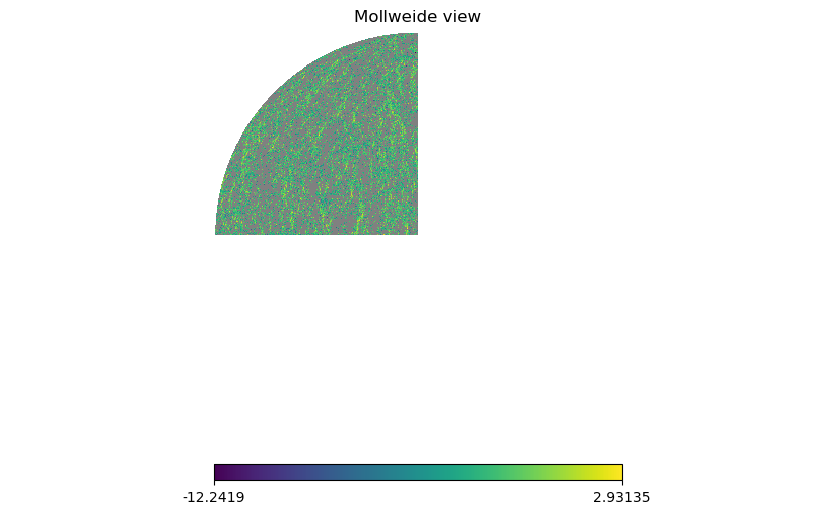

/tmp/ipykernel_1190604/723612356.py:26: RuntimeWarning: divide by zero encountered in log
  hp.cartview(np.log(t_maps[:,1]), cbar=True, lonra=lonra, latra=latra,
/tmp/ipykernel_1190604/723612356.py:26: RuntimeWarning: invalid value encountered in log
  hp.cartview(np.log(t_maps[:,1]), cbar=True, lonra=lonra, latra=latra,


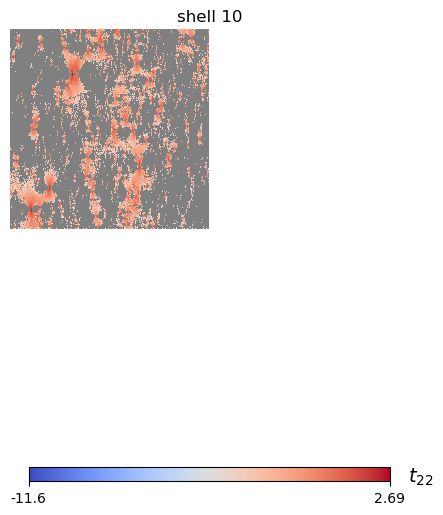

/tmp/ipykernel_1190604/723612356.py:34: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(t_maps[:,2]), nest=False)
/tmp/ipykernel_1190604/723612356.py:34: RuntimeWarning: invalid value encountered in log
  hp.mollview(np.log(t_maps[:,2]), nest=False)


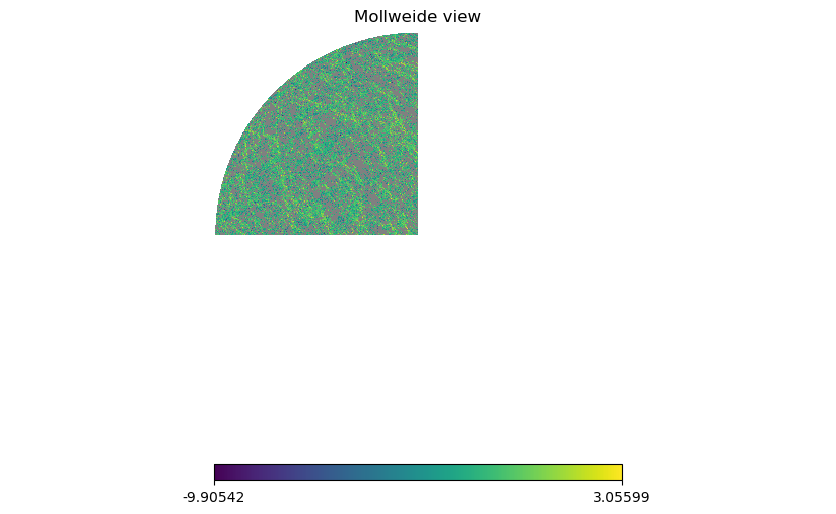

/tmp/ipykernel_1190604/723612356.py:37: RuntimeWarning: divide by zero encountered in log
  hp.cartview(np.log(t_maps[:,2]), cbar=True, lonra=lonra, latra=latra,
/tmp/ipykernel_1190604/723612356.py:37: RuntimeWarning: invalid value encountered in log
  hp.cartview(np.log(t_maps[:,2]), cbar=True, lonra=lonra, latra=latra,


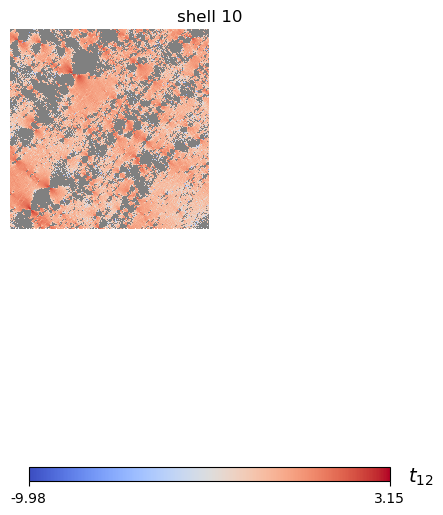

In [9]:
print("POLLUX")
t_maps = hpmap_tidal_pollux(snap_no)
print("s11:",np.min(t_maps[:,0]),np.max(t_maps[:,0]), np.mean(t_maps[:,0]))
print("s22:",np.min(t_maps[:,1]),np.max(t_maps[:,1]), np.mean(t_maps[:,1]))
print("s12:",np.min(t_maps[:,2]),np.max(t_maps[:,2]), np.mean(t_maps[:,2]))

#print("s11:",np.min(hpmap_tidal_pollux(snap_no)[:,0]), np.max(hpmap_tidal_pollux(snap_no)[:,0]), np.mean(hpmap_tidal_pollux(snap_no)[:,0]))
#print("s22:",np.min(hpmap_tidal_pollux(snap_no)[:,1]), np.max(hpmap_tidal_pollux(snap_no)[:,1]), np.mean(hpmap_tidal_pollux(snap_no)[:,1]))
#print("s12:",np.min(hpmap_tidal_pollux(snap_no)[:,2]), np.max(hpmap_tidal_pollux(snap_no)[:,2]), np.mean(hpmap_tidal_pollux(snap_no)[:,2]))


hp.mollview(np.log(t_maps[:,0]), nest=False)
plt.show()

hp.cartview(np.log(t_maps[:,0]), cbar=True, lonra=lonra, latra=latra,
            nest=False,
            title="shell "+str(snap_no),
            # min=-10, max=0,
            cmap=plt.cm.coolwarm,            
            norm=None, unit='$t_{11}$')
plt.show()

hp.mollview(np.log(t_maps[:,1]), nest=False)
plt.show()

hp.cartview(np.log(t_maps[:,1]), cbar=True, lonra=lonra, latra=latra,
            nest=False,
            title="shell "+str(snap_no),
            # min=-10, max=0,
            cmap=plt.cm.coolwarm,            
            norm=None, unit='$t_{22}$')
plt.show()

hp.mollview(np.log(t_maps[:,2]), nest=False)
plt.show()

hp.cartview(np.log(t_maps[:,2]), cbar=True, lonra=lonra, latra=latra,
            nest=False,
            title="shell "+str(snap_no),
            # min=-10, max=0,
            cmap=plt.cm.coolwarm,            
            norm=None, unit='$t_{12}$')
plt.show()


In [21]:
!ls /pscratch/sd/j/jmena/HOS_Sims_baryonified/dmb/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/
#ls /pscratch/sd/j/jmena/HOS_Sims_/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/kappa_zsnapshots/

cosmo_ccl.yaml
kappa_zsnapshots
shell_hacc_seed0_nside8192_alms_imap0.fits
shell_hacc_seed0_nside8192_alms_imap10.fits
shell_hacc_seed0_nside8192_alms_imap11.fits
shell_hacc_seed0_nside8192_alms_imap12.fits
shell_hacc_seed0_nside8192_alms_imap13.fits
shell_hacc_seed0_nside8192_alms_imap14.fits
shell_hacc_seed0_nside8192_alms_imap15.fits
shell_hacc_seed0_nside8192_alms_imap16.fits
shell_hacc_seed0_nside8192_alms_imap17.fits
shell_hacc_seed0_nside8192_alms_imap18.fits
shell_hacc_seed0_nside8192_alms_imap19.fits
shell_hacc_seed0_nside8192_alms_imap1.fits
shell_hacc_seed0_nside8192_alms_imap20.fits
shell_hacc_seed0_nside8192_alms_imap21.fits
shell_hacc_seed0_nside8192_alms_imap22.fits
shell_hacc_seed0_nside8192_alms_imap23.fits
shell_hacc_seed0_nside8192_alms_imap24.fits
shell_hacc_seed0_nside8192_alms_imap25.fits
shell_hacc_seed0_nside8192_alms_imap26.fits
shell_hacc_seed0_nside8192_alms_imap27.fits
shell_hacc_seed0_nside8192_alms_imap28.fits
shell_hacc_seed0_nside8192_alms_imap29.fits
sh

In [8]:
def scale_cls(c):
    ells = np.arange(len(c))
    return ells, ells*(ells+1)*c/(np.pi*2)

# hp.alm2cl(hp.map2alm(baryon_map_eta_tot_0pt5))

In [12]:
def Compute_Cl_pollux(snap_no,s_comp):
 
    #Norm_empirical = 0.6525 
    Norm_empirical = 0.6526*(114/delta_chi[snap_no])**(-0.5)

    
    if s_comp == 11:      
        a = healsparse.HealSparseMap.read(fname_tidal_pollux11(snap_no))
        tmp = a.generate_healpix_map()
        
        # turn masked pixels to zero.
        tmp[tmp<-1.0e+30]=0
            
        #Note, these maps are Nested ordered, not ring ordered.
        hpmap_tidal_= hp.reorder(tmp, n2r = True)*Norm_empirical
        del tmp
        Cl = hp.sphtfunc.anafast(hpmap_tidal_, map2=None, nspec=None, lmax=1000, mmax=None, iter=1, alm=False, 
                                 pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)
    if s_comp == 22:  
        a = healsparse.HealSparseMap.read(fname_tidal_pollux22(snap_no))
        tmp = a.generate_healpix_map()
        
        # turn masked pixels to zero.
        tmp[tmp<-1.0e+30]=0
    
        #Note, these maps are Nested ordered, not ring ordered.
        hpmap_tidal_= hp.reorder(tmp, n2r = True)*Norm_empirical
        del tmp
        Cl = hp.sphtfunc.anafast(hpmap_tidal_, map2=None, nspec=None, lmax=1000, mmax=None, iter=1, alm=False, 
                                 pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)
    if s_comp == 12:  
        a = healsparse.HealSparseMap.read(fname_tidal_pollux12(snap_no))
        tmp = a.generate_healpix_map()
        
        # turn masked pixels to zero.
        tmp[tmp<-1.0e+30]=0
    
        #Note, these maps are Nested ordered, not ring ordered.
        hpmap_tidal_= hp.reorder(tmp, n2r = True)*Norm_empirical
        del tmp
        Cl = hp.sphtfunc.anafast(hpmap_tidal_, map2=None, nspec=None, lmax=1000, mmax=None, iter=1, alm=False, 
                                 pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)

    Cl *= 8.0

    return Cl
    

In [10]:
def Compute_Cl_ss(snap_no, s_comp):
    kpmap_ring = np.load(fname_tidal_ss(snap_no))
    Norm_empirical = 0.6525 
    kpmap_ring *= Norm_empirical
    if s_comp == 11:  
        Cl = hp.sphtfunc.anafast(kpmap_ring[:,0], map2=None, nspec=None, lmax=1000, mmax=None, iter=1, alm=False, 
                                 pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)
    if s_comp == 22:  
        Cl = hp.sphtfunc.anafast(kpmap_ring[:,1], map2=None, nspec=None, lmax=1000, mmax=None, iter=1, alm=False, 
                                 pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)
    if s_comp == 12:  
        Cl = hp.sphtfunc.anafast(kpmap_ring[:,2], map2=None, nspec=None, lmax=1000, mmax=None, iter=1, alm=False, 
                                 pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)
    # Cl = hp.alm2cl(hp.map2alm(kpmap_ring[:,0]))
    Cl *= 8.0
    return Cl

def Compute_Cl_hc(snap_no, s_comp):
    kpmap_ring = np.load(fname_tidal_hc(snap_no))
    #
    # Trying to find an empirical solution. DGrowth**2 varies by 8% at most at z = 4
    #norm_HACC = 2.0 #4/3
    #Norm_empirical = 71/delta_chi[snap_no]
    #Norm_empirical = 0.6526*np.sqrt(114/2/delta_chi[snap_no])
    Norm_empirical = 0.6526*(114/delta_chi[snap_no])**(-0.5)
    #Norm_empirical = 0.6526*(114/2/delta_chi[snap_no])**(-1)
    #Norm_empirical = 0.6526*(114/2/delta_chi[snap_no])**(-1.2)*0.52
    #Norm_empirical = 0.6526*(114/2/delta_chi[snap_no])**0.25
    #Norm_empirical = 0.6526
    kpmap_ring *= Norm_empirical
    if s_comp == 11:  
        Cl = hp.sphtfunc.anafast(kpmap_ring[:,0], map2=None, nspec=None, lmax=1000, mmax=None, iter=1, alm=False, 
                                 pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)
    if s_comp == 22:  
        Cl = hp.sphtfunc.anafast(kpmap_ring[:,1], map2=None, nspec=None, lmax=1000, mmax=None, iter=1, alm=False, 
                                 pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)
    if s_comp == 12:  
        Cl = hp.sphtfunc.anafast(kpmap_ring[:,2], map2=None, nspec=None, lmax=1000, mmax=None, iter=1, alm=False, 
                                 pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)
    # Cl = hp.alm2cl(hp.map2alm(kpmap_ring[:,0]))
    Cl *= 8.0
    return Cl
    
# fname = input.kappaDir+np.str("{:5.4f}".format(zs))+"kappa.npy"
# kpmap_ring = np.load(fname)
# print("loaded kappa")
# # Compute C_ell:
# Cl = hp.sphtfunc.anafast(kpmap_ring, map2=None, nspec=None, lmax=5000, mmax=None, iter=1, alm=False, pol=False, use_weights=False, datapath=None, gal_cut=0, use_pixel_weights=False)
# Cl *= 8.0
# print("Got C_ell")
# fname = input.kappaDir+np.str("{:5.4f}".format(zs))+"Cl.dat"
# np.savetxt(fname,Cl)
# print("Saved C_ell")

working on z =  0.05015674 0.0502


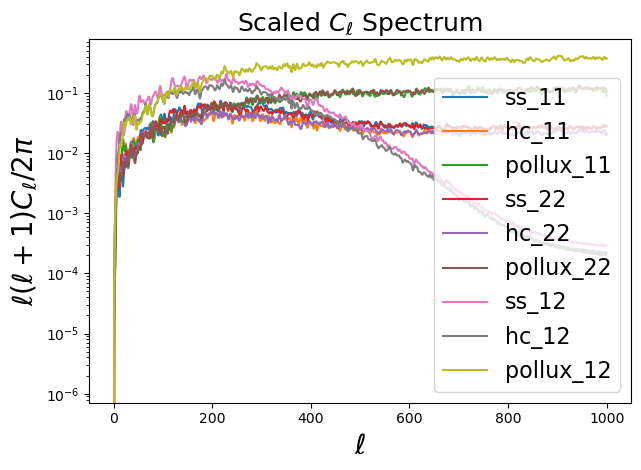

/tmp/ipykernel_276526/1053481209.py:60: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, Cl_scaled_11_ss/Cl_scaled_11_hc, label=f'hc_11')
/tmp/ipykernel_276526/1053481209.py:61: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, Cl_scaled_22_ss/Cl_scaled_22_hc, label=f'hc_22')
/tmp/ipykernel_276526/1053481209.py:62: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, Cl_scaled_12_ss/Cl_scaled_12_hc, label=f'hc_12')
/tmp/ipykernel_276526/1053481209.py:63: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, Cl_scaled_11_ss/Cl_scaled_11_pollux, label=f'pollux_11')
/tmp/ipykernel_276526/1053481209.py:64: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, Cl_scaled_22_ss/Cl_scaled_22_pollux, label=f'pollux_22')
/tmp/ipykernel_276526/1053481209.py:65: RuntimeWarning: invalid value encountered in divide
  plt.plot(ells, Cl_scaled_12_ss/Cl_scaled_12_pollux, label=f'pollux_12')


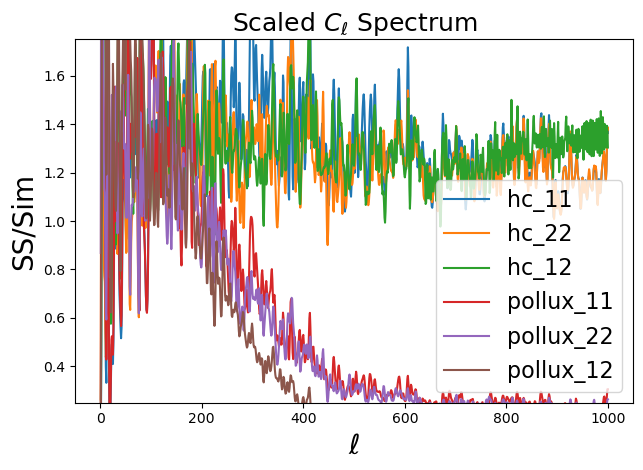

working on z =  0.10561056 0.1008


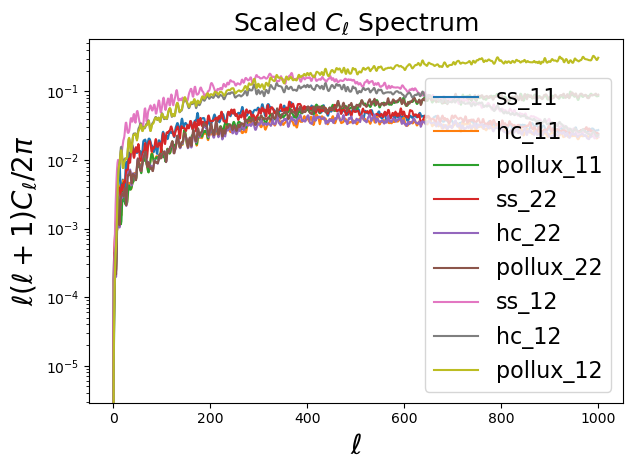

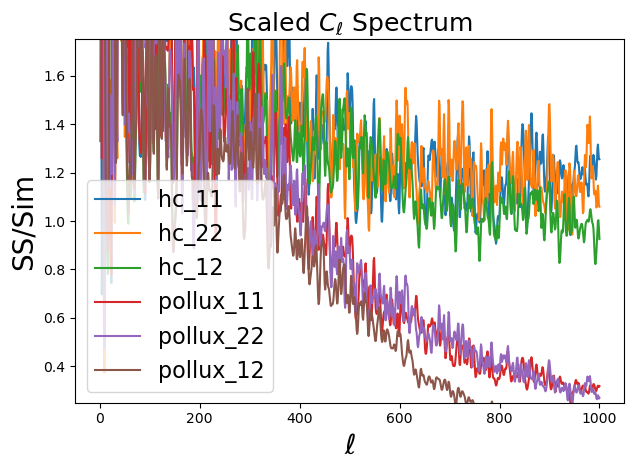

working on z =  0.12541993 0.1279


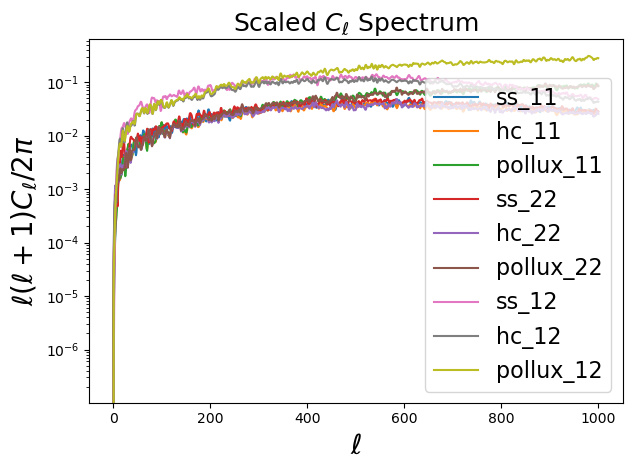

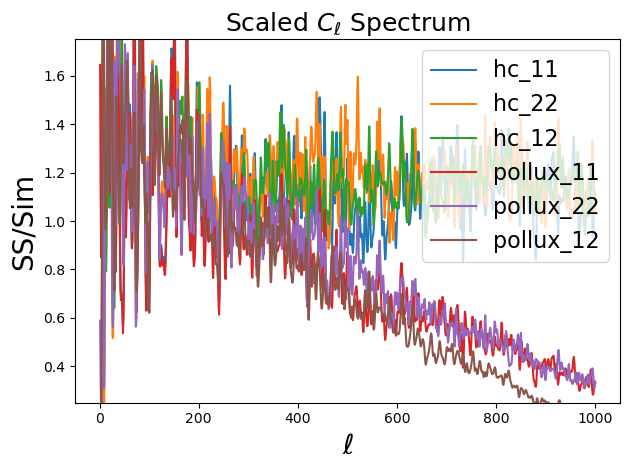

working on z =  0.21230398 0.2123


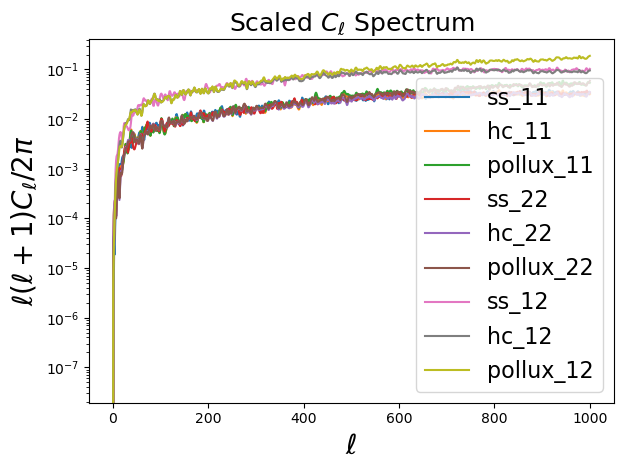

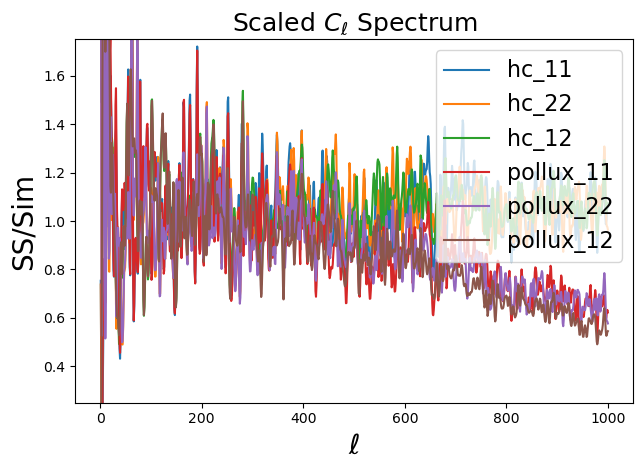

working on z =  0.40167364 0.4017


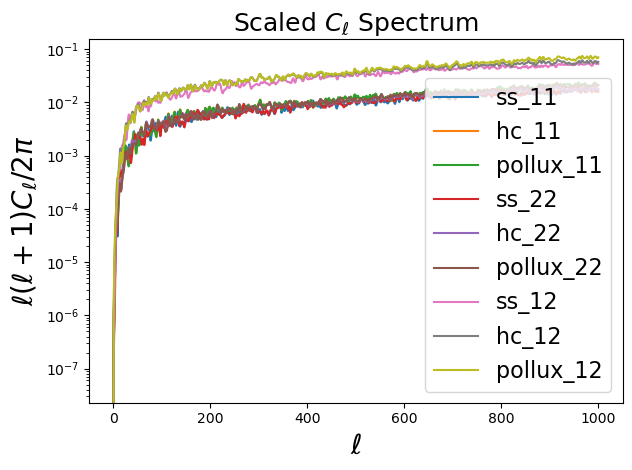

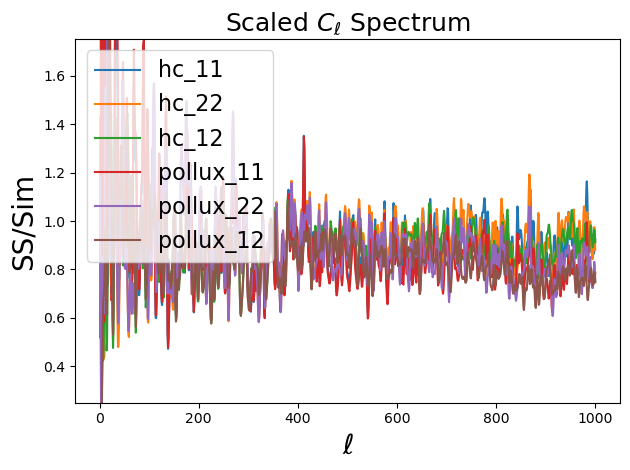

working on z =  0.50224215 0.5022


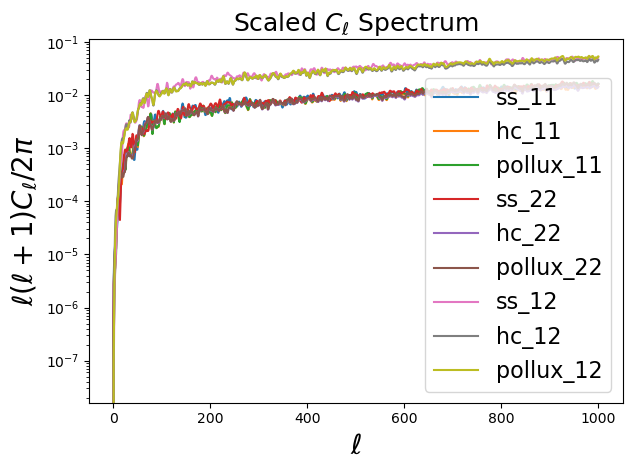

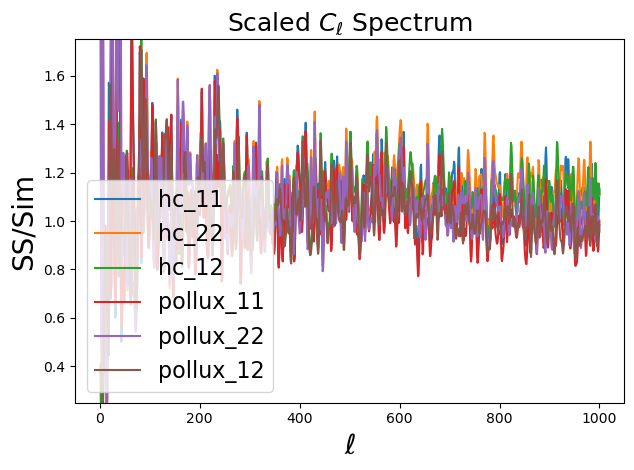

working on z =  1.10691824 1.1069


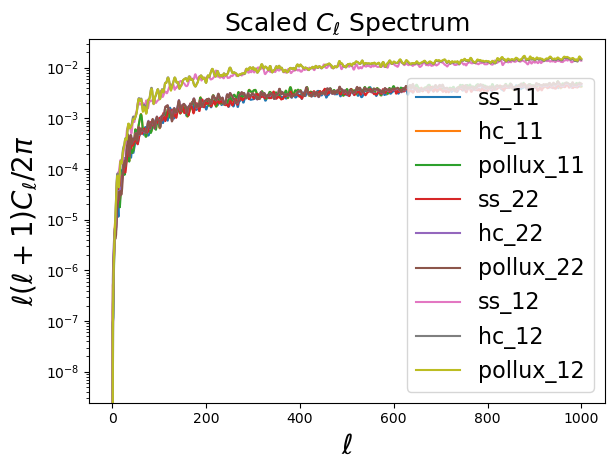

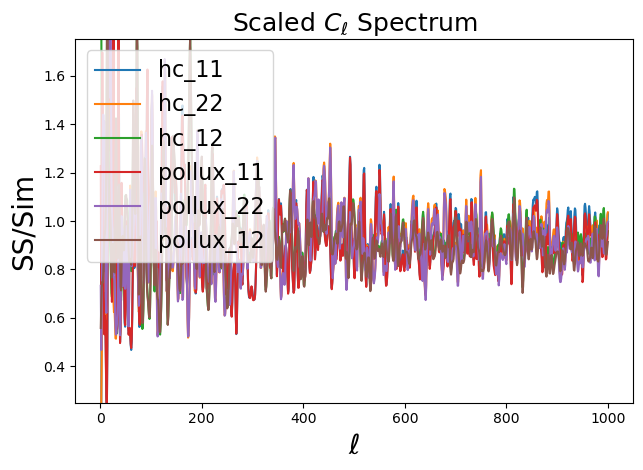

working on z =  2.01801802 2.018


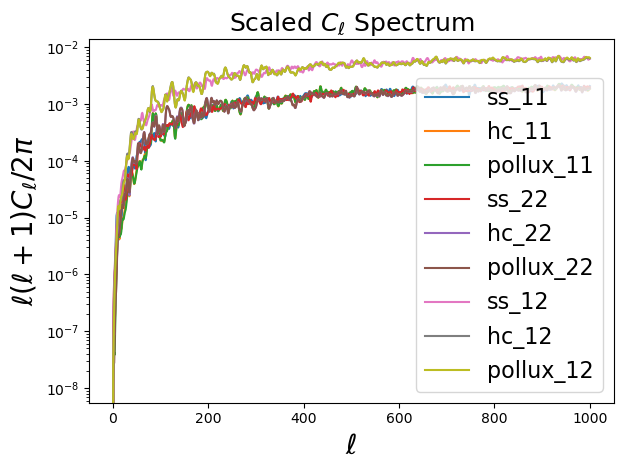

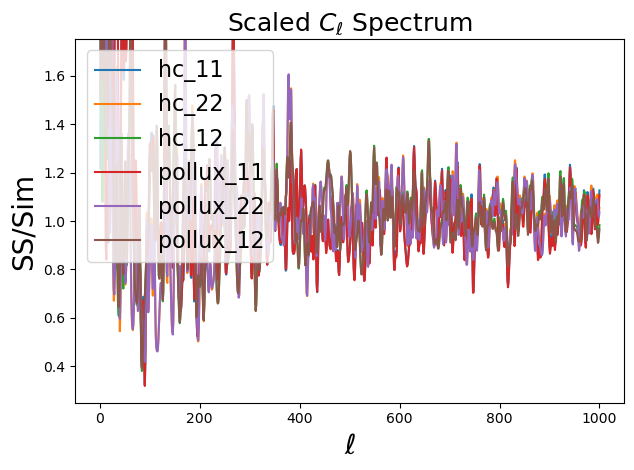

In [13]:
#for snap_no in range(1,50):  # example snapshot number
#for snap_no in 5, 10, 15, 20, 25, 30, 40, 50:  # example snapshot number

match_z_hc = np.array([3, 6, 7, 11, 18, 21, 33, 42])
match_z_ss = np.array([1, 3, 4, 7, 13, 16, 29, 44])
for i in range(8):
    print('working on z = ',z_shell[match_z_hc[i]], z_list_ss[match_z_ss[i]])

    snap_no = match_z_ss[i]
    Cl_11_ss = Compute_Cl_ss(snap_no, 11)
    Cl_22_ss = Compute_Cl_ss(snap_no, 22)
    Cl_12_ss = Compute_Cl_ss(snap_no, 12)
    
    snap_no = match_z_hc[i]
    Cl_11_hc = Compute_Cl_hc(snap_no, 11)
    Cl_22_hc = Compute_Cl_hc(snap_no, 22)
    Cl_12_hc = Compute_Cl_hc(snap_no, 12)

    Cl_11_pollux = Compute_Cl_pollux(snap_no, 11)
    Cl_22_pollux = Compute_Cl_pollux(snap_no, 22)
    Cl_12_pollux = Compute_Cl_pollux(snap_no, 12)

    
    ells, Cl_scaled_11_ss = scale_cls(Cl_11_ss)
    ells, Cl_scaled_22_ss = scale_cls(Cl_22_ss)
    ells, Cl_scaled_12_ss = scale_cls(Cl_12_ss)
    
    ells, Cl_scaled_11_hc = scale_cls(Cl_11_hc)
    ells, Cl_scaled_22_hc = scale_cls(Cl_22_hc)
    ells, Cl_scaled_12_hc = scale_cls(Cl_12_hc)

    ells, Cl_scaled_11_pollux = scale_cls(Cl_11_pollux)
    ells, Cl_scaled_22_pollux = scale_cls(Cl_22_pollux)
    ells, Cl_scaled_12_pollux = scale_cls(Cl_12_pollux)

    # plt.figure(figsize=(8, 5))
    plt.plot(ells, Cl_scaled_11_ss, label=f'ss_11')
    plt.plot(ells, Cl_scaled_11_hc, label=f'hc_11')
    plt.plot(ells, Cl_scaled_11_pollux, label=f'pollux_11')
    plt.plot(ells, Cl_scaled_22_ss, label=f'ss_22')
    plt.plot(ells, Cl_scaled_22_hc, label=f'hc_22')
    plt.plot(ells, Cl_scaled_22_pollux, label=f'pollux_22')
    plt.plot(ells, Cl_scaled_12_ss, label=f'ss_12')
    plt.plot(ells, Cl_scaled_12_hc, label=f'hc_12')
    plt.plot(ells, Cl_scaled_12_pollux, label=f'pollux_12')
    
    # plt.plot(ells, Cl_scaled_12, label=f'12')
    # plt.plot(ells, Cl_scaled_22, label=f'22')
    
    plt.xlabel(r'$\ell$', fontsize=20)
    plt.ylabel(r'$\ell(\ell+1)C_\ell / 2\pi$', fontsize=20)
    plt.title(r'Scaled $C_\ell$ Spectrum', fontsize=18)
    # plt.grid(True, which='both', ls=':')
    plt.legend(fontsize=16)
    plt.tight_layout()
    plt.yscale('log')
    # plt.ylim(0,400)
    plt.show()

    plt.plot(ells, Cl_scaled_11_ss/Cl_scaled_11_hc, label=f'hc_11')
    plt.plot(ells, Cl_scaled_22_ss/Cl_scaled_22_hc, label=f'hc_22')
    plt.plot(ells, Cl_scaled_12_ss/Cl_scaled_12_hc, label=f'hc_12')
    plt.plot(ells, Cl_scaled_11_ss/Cl_scaled_11_pollux, label=f'pollux_11')
    plt.plot(ells, Cl_scaled_22_ss/Cl_scaled_22_pollux, label=f'pollux_22')
    plt.plot(ells, Cl_scaled_12_ss/Cl_scaled_12_pollux, label=f'pollux_12')
    
    # plt.plot(ells, Cl_scaled_12, label=f'12')
    # plt.plot(ells, Cl_scaled_22, label=f'22')
    
    plt.xlabel(r'$\ell$', fontsize=20)
    plt.ylabel(r'SS/Sim', fontsize=20)
    plt.title(r'Scaled $C_\ell$ Spectrum', fontsize=18)
    # plt.grid(True, which='both', ls=':')
    plt.legend(fontsize=16)
    plt.tight_layout()
    #plt.yscale('log')
    plt.ylim(0.25,1.75)
    plt.show()

In [20]:
from astropy.cosmology import FlatLambdaCDM
# Compute shell thickness factor H0/chi_shell
#SkySim: Chi_shell = 114
print('SkySim: ',71/114)

#HACC: Chi_shell varies with redshift
cosmo = FlatLambdaCDM(H0=71, Om0=0.2648, Tcmb0=2.725)
chi_max = np.array(cosmo.comoving_distance(array['zmax']))
chi_min = np.array(cosmo.comoving_distance(array['zmin']))
delta_chi = chi_max - chi_min
norm = 2/3
for i in range(10,25):
    #print('HACC:',71/delta_chi[i])
    print('ratio:',(71/114) / (71/delta_chi[i])*norm)

SkySim:  0.6228070175438597
ratio: 0.5117642592245903
ratio: 0.5258828750480329
ratio: 0.5404598660782052
ratio: 0.5555072947383852
ratio: 0.5710364731852909
ratio: 0.5870593539582547
ratio: 0.6035879463382273
ratio: 0.6206333792313709
ratio: 0.6382064610955078
ratio: 0.6563191235539543
ratio: 0.6749818752044623
ratio: 0.6942058160240859
ratio: 0.7140021279031528
ratio: 0.7343822599703356
ratio: 0.7553578984327128


In [35]:
import pyccl as ccl
cosmo_HACC = ccl.Cosmology(
    Omega_c=0.22, Omega_b=0.0448, 
    h=0.71, sigma8 = 0.801, n_s= 0.963,w0=-1.00,wa=0.0, Omega_k=0.0)
cosmo_SkySim = ccl.Cosmology(
    Omega_c=0.2676, Omega_b=0.0448, 
    h=0.71, sigma8 = 0.801, n_s= 0.963,w0=-1.00,wa=0.0, Omega_k=0.0)


In [41]:
for z in np.linspace(0,4,50) :    
    print(z,ccl.growth_factor(cosmo_HACC, 1./(1+z))**2/ccl.growth_factor(cosmo_SkySim, 1./(1+z))**2)


0.0 1.0
0.08163265306122448 1.0074295960944575
0.16326530612244897 1.0143918791103688
0.24489795918367346 1.020838567662196
0.32653061224489793 1.026747976950691
0.4081632653061224 1.0321201908903417
0.4897959183673469 1.0369717133850638
0.5714285714285714 1.0413302737323584
0.6530612244897959 1.0452307684115427
0.7346938775510203 1.048711697041582
0.8163265306122448 1.0518123125963186
0.8979591836734693 1.0545715968387146
0.9795918367346939 1.0570260897684602
1.0612244897959182 1.0592098213731242
1.1428571428571428 1.0611538311621447
1.2244897959183672 1.0628860846419121
1.3061224489795917 1.0644315429865052
1.3877551020408163 1.0658123484694735
1.4693877551020407 1.067047965758245
1.5510204081632653 1.068155621110293
1.6326530612244896 1.0691503698288873
1.7142857142857142 1.0700453852257805
1.7959183673469385 1.0708522026828227
1.8775510204081631 1.0715809149639164
1.9591836734693877 1.0722403593041103
2.0408163265306123 1.072838327209995
2.1224489795918364 1.0733814474097225
2.2040

In [34]:
0.3124 - 0.0448

0.2676

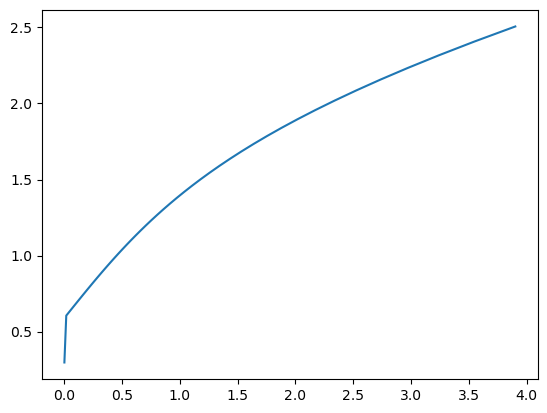

In [51]:
plt.plot(z_shell,delta_chi/114)
#plt.loglog(z_shell,np.sqrt(delta_chi))
#plt.loglog(z_shell,(delta_chi)**0.25)


In [20]:
print(z_list_ss)

[0.0245 0.0502 0.0749 0.1008 0.1279 0.1538 0.1837 0.2123 0.2423 0.2705
 0.3035 0.3347 0.3636 0.4017 0.4337 0.4714 0.5022 0.5391 0.5777 0.6184
 0.6557 0.6948 0.7358 0.7788 0.824  0.8646 0.9591 1.006  1.0552 1.1069
 1.152  1.2088 1.2584 1.321  1.3759 1.4334 1.4938 1.5443 1.6104 1.68
 1.7384 1.7994 1.8797 1.9472 2.018  2.0923 2.1703 2.2524 2.3168 2.4068
 2.4775 2.5765 2.6545 2.7361 2.8506 2.9412 3.0361]


In [19]:
print(snaplist_ss )

[487 475 464 453 442 432 421 411 401 392 382 373 365 355 347 338 331 323
 315 307 300 293 286 279 272 266 253 247 241 235 230 224 219 213 208 203
 198 194 189 184 180 176 171 167 163 159 155 151 148 144 141 137 134 131
 127 124 121]


In [21]:
print(z_shell)

[0.         0.01617796 0.03288798 0.05015674 0.06801275 0.08648649
 0.10561056 0.12541993 0.14595211 0.16724739 0.18934911 0.21230398
 0.23616236 0.26097867 0.28681178 0.31372549 0.34178905 0.37107776
 0.40167364 0.43366619 0.46715328 0.50224215 0.53905054 0.57770801
 0.61835749 0.66115702 0.70628183 0.7539267  0.8043088  0.85767098
 0.91428571 0.97445972 1.03853955 1.10691824 1.18004338 1.25842697
 1.34265734 1.43341404 1.53148615 1.63779528 1.75342466 1.87965616
 2.01801802 2.170347   2.33887043 2.52631579 2.73605948 2.97233202
 3.24050633 3.54751131 3.90243902]


In [25]:
print(z_shell[[3, 6, 7, 11, 18, 21, 33, 42]])

[0.05015674 0.10561056 0.12541993 0.21230398 0.40167364 0.50224215
 1.10691824 2.01801802]


In [26]:
print(z_list_ss[[1, 3, 4, 7, 13, 16, 29, 44]])

[0.0502 0.1008 0.1279 0.2123 0.4017 0.5022 1.1069 2.018 ]


In [34]:
match_z_hc = np.array([3, 6, 7, 11, 18, 21, 33, 42])
match_z_ss = np.array([1, 3, 4, 7, 13, 16, 29, 44])
for i in range(8):
    #print(match_z_hc[i],match_z_ss[i])
    print(z_shell[match_z_hc[i]], z_list_ss[match_z_ss[i]])

0.05015674 0.0502
0.10561056 0.1008
0.12541993 0.1279
0.21230398 0.2123
0.40167364 0.4017
0.50224215 0.5022
1.10691824 1.1069
2.01801802 2.018


In [55]:
np.save('HACC_51shells.dat', shell_array)

In [21]:
from astropy.io import fits

folder_path='/pscratch/sd/j/jmena/HOS_Sims/HACC150_3/shells_z51_subsampledensitymax1.5_nside8192/'
filename1='shell_hacc_seed0_nside8192_t11_imap0.fits'
hdul1=fits.open(folder_path+filename1)
data1=hdul1[1].data
header1=hdul1[1].header


In [ ]:
#Project to 10x10 flat sky:
mass = np.zeros(hp.nside2npix(lc.nside), dtype = np.float32)
with h5py.File(lc.output_dir+f'kappa_maps.hdf5', 'r') as f:
    for zi, z in enumerate(z_source):
        mass = f[f"zs{np.round(z,2)}"][()]
        hp.cartview(mass, title = f'Kappa map {zi}', cbar = True, rot = [0, 90],
                                lonra = [-np.degrees(lc.field[0])/2, np.degrees(lc.field[0])/2], latra = [-np.degrees(lc.field[1])/2, np.degrees(lc.field[1])/2])

        #Project to 10x10 flat sky:
        ####### free parameters to define the patch to cut out (next 3 lines)
        ra0, dec0 = 0, 90 ## center of the patch, unit: degrees; ra, dec both go from [0, 90] deg
        mapsize = 9.8 # map size in degrees
        Npix = 7745
        res_arcmin = mapsize*60/Npix

        #res_arcmin = 0.1 # map resolution in arcmin/pix
        #Npix = mapsize*60/res_arcmin # number of pixels to cut out (per side)

        map_flat = hp.gnomview(mass, rot=[ra0, dec0], unit="kappa", format="%.2g",
                               title="GnomView (RA_center=%s, DEC_center=%s)" %(ra0, dec0), 
                               xsize=Npix, ## number of pixels 
                               reso=res_arcmin, ## resolution in arcmin
                               # norm="hist",
                               min=-0.06,
                               max=0.06,
                               return_projected_map=True)

        ###### show this again with our usual imshow
        plt.imshow(map_flat, vmin=-0.06, vmax=0.4, origin='lower', extent=[ra0-mapsize/2,ra0+mapsize/2, dec0-mapsize/2,dec0+mapsize/2])
        plt.xlabel('RA'); plt.ylabel('DEC')
        plt.colorbar()
        plt.title('a flat sky patch')
        plt.show()